In [55]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

### Loading images from GitHub


In [56]:
def get_filename(image_id):
  return f"in{image_id:06d}.jpg"

def get_ground_truth_filename(image_id):
  return f"gt{image_id:06d}.png"

In [57]:
def load_images(url, output_folder, img_count):
  images = []

  os.makedirs(output_folder, exist_ok=True)

  for i in range(img_count):
      fileName = get_filename(i)

      full_path = os.path.join(output_folder, fileName)

      if not os.path.exists(full_path):
        r = requests.get(url + fileName, allow_redirects=True)
        open(full_path, "wb").write(r.content)

      img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
      images.append(img)

  print("Loaded", len(images), "images")
  return images

In [58]:
def load_ground_truth(url, output_folder, img_count):
  ground_truth = []

  os.makedirs(output_folder, exist_ok=True)

  for i in range(img_count):
      fileName = get_ground_truth_filename(i)

      full_path = os.path.join(output_folder, fileName)

      if not os.path.exists(full_path):
        r = requests.get(url + fileName, allow_redirects=True)
        open(full_path, "wb").write(r.content)

      img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
      ground_truth.append(img)

  print("Loaded", len(ground_truth), "images")
  return ground_truth

In [59]:
url_pedestrian = "https://raw.githubusercontent.com/vision-agh/zaw_avs_materials/main/lab02_cfd/pedestrian/input/"
url_highway = "https://raw.githubusercontent.com/vision-agh/zaw_avs_materials/main/lab02_cfd/highway/input/"
url_office = "https://raw.githubusercontent.com/vision-agh/zaw_avs_materials/main/lab02_cfd/office/input/"

img_pedestrian = load_images(url_pedestrian, "pedestrian", 1100)
img_highway = load_images(url_highway, "highway", 1700)
img_office = load_images(url_office, "office", 2050)

Loaded 1100 images
Loaded 1700 images
Loaded 2050 images


In [60]:
url_pedestrian = "https://raw.githubusercontent.com/vision-agh/zaw_avs_materials/main/lab02_cfd/pedestrian/groundtruth/"
url_highway = "https://raw.githubusercontent.com/vision-agh/zaw_avs_materials/main/lab02_cfd/highway/groundtruth/"
url_office = "https://raw.githubusercontent.com/vision-agh/zaw_avs_materials/main/lab02_cfd/office/groundtruth/"

gt_pedestrian = load_ground_truth(url_pedestrian, "pedestrian", 1100)
gt_highway = load_ground_truth(url_highway, "highway", 1700)
gt_office = load_ground_truth(url_office, "office", 2050)

Loaded 1100 images
Loaded 1700 images
Loaded 2050 images


### Detection of movement between frames and image processing

In [61]:
def detect_movement(image_id, images):
  image1 = images[image_id]
  image2 = images[image_id - 1]
  return np.abs(image1.astype("int16") - image2.astype("int16")).astype("uint8")

In [62]:
def fill_holes(image):
    img = image.copy()

    h, w = img.shape
    mask = np.zeros((h+2, w+2), np.uint8)

    cv2.floodFill(img, mask, (0, 0), 255)
    img_inv = cv2.bitwise_not(img)
    filled = image | img_inv

    return filled

In [63]:
def process_movement(image_id, images):
  (T, img) = cv2.threshold(detect_movement(image_id, images), 17, 255, cv2.THRESH_BINARY)
  img = cv2.medianBlur(img, 5)

  for _ in range(5):
    img = cv2.erode(img, (5, 5))

  for _ in range(5):
    img = cv2.dilate(img, (11, 11))

  img = cv2.morphologyEx(img, cv2.MORPH_CLOSE, (5, 5))

  img = fill_holes(img)

  return img

### Binary images after using thresholding, median filter and morphological operations


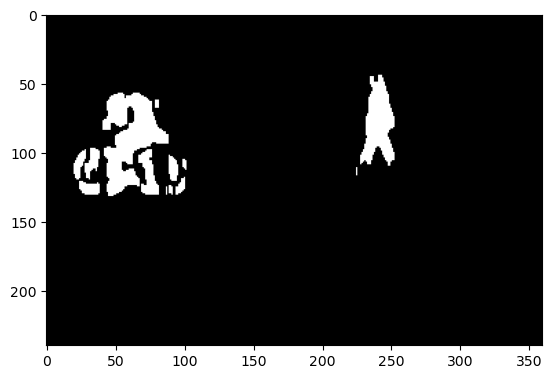

In [64]:
plt.gray()
test_image = process_movement(470, img_pedestrian)
plt.imshow(test_image)

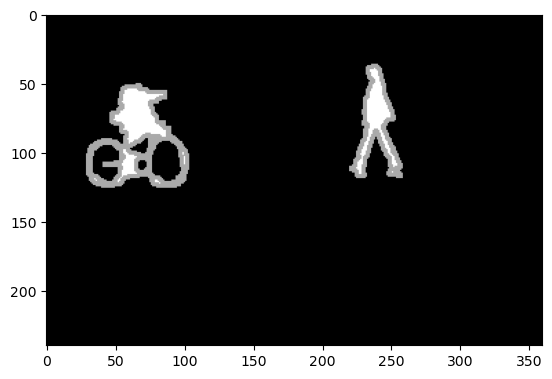

In [65]:
plt.imshow(gt_pedestrian[470])

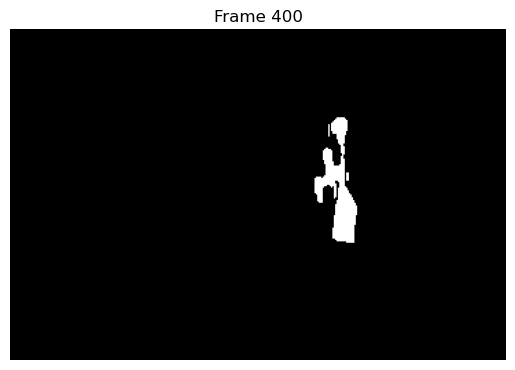

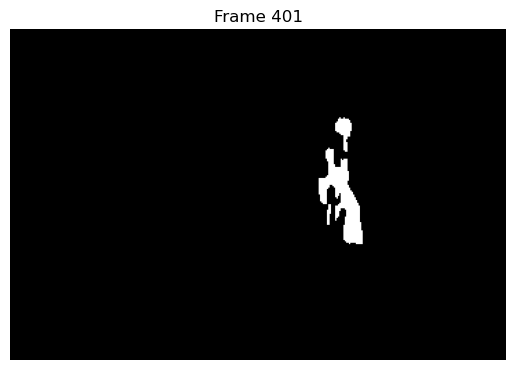

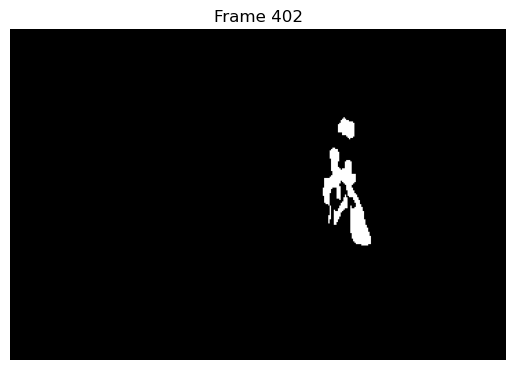

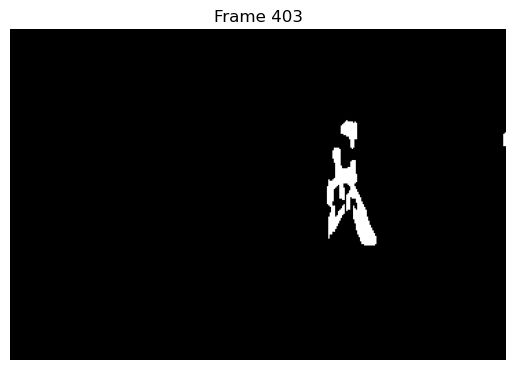

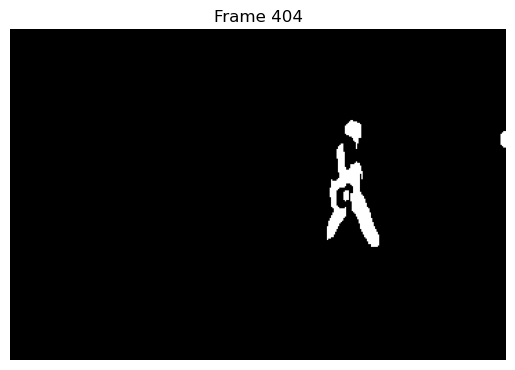

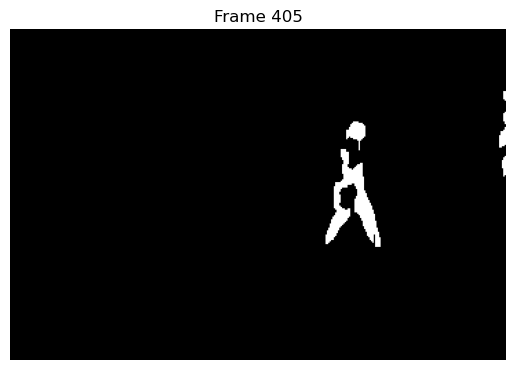

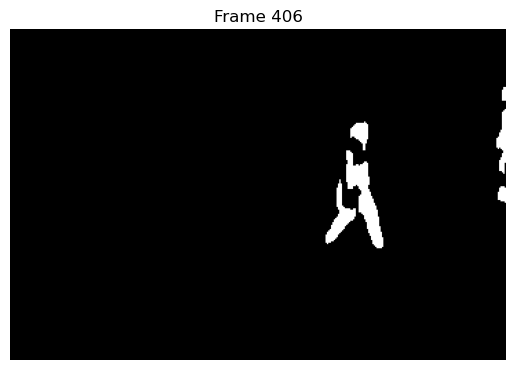

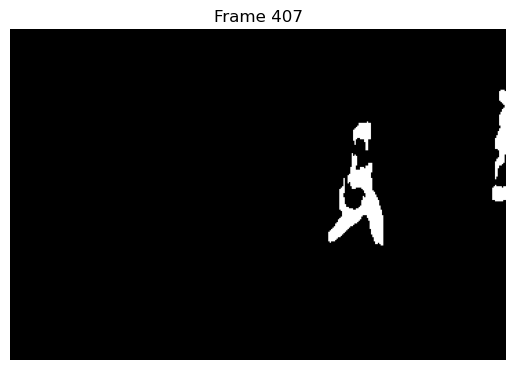

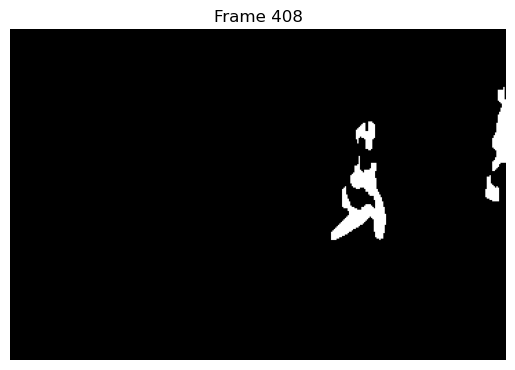

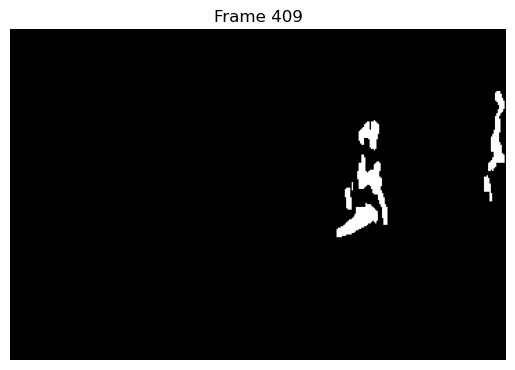

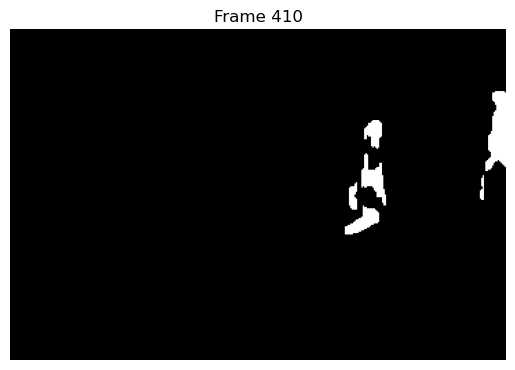

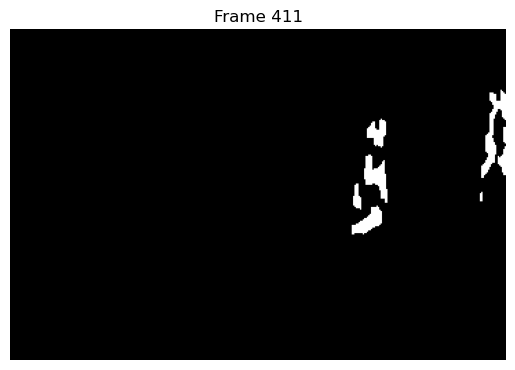

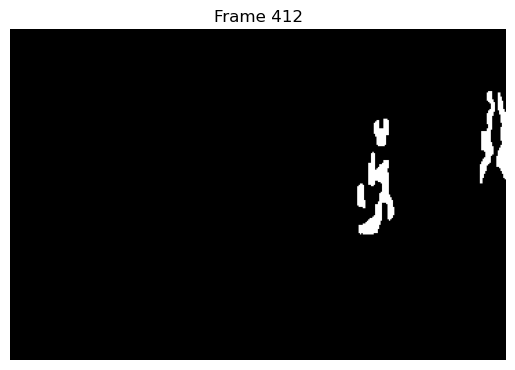

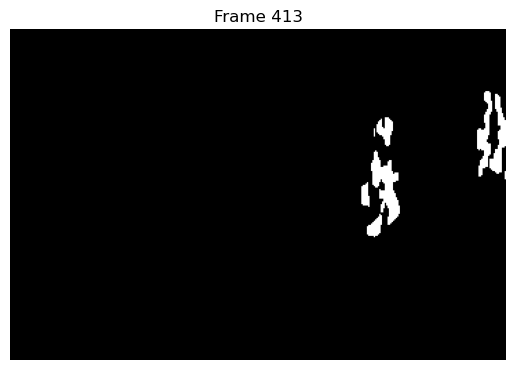

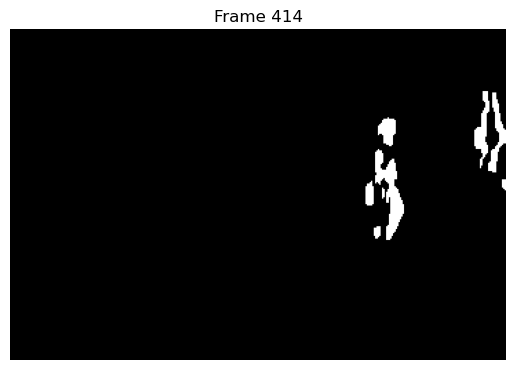

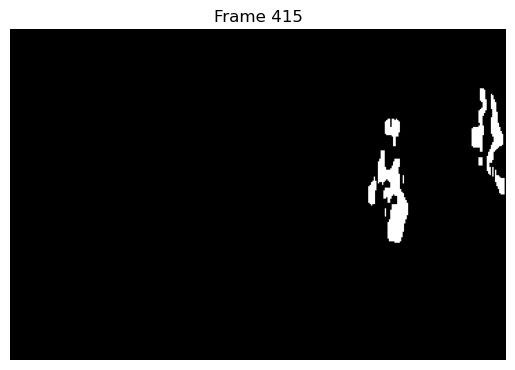

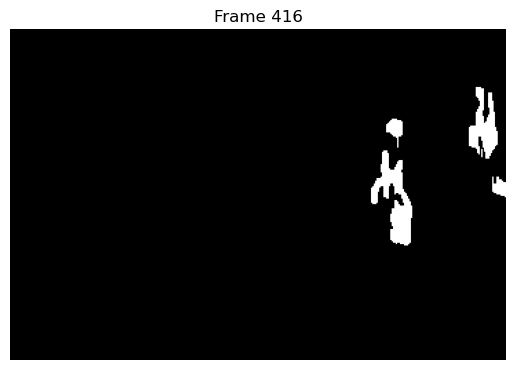

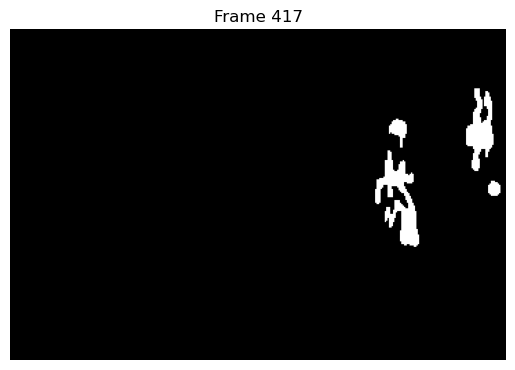

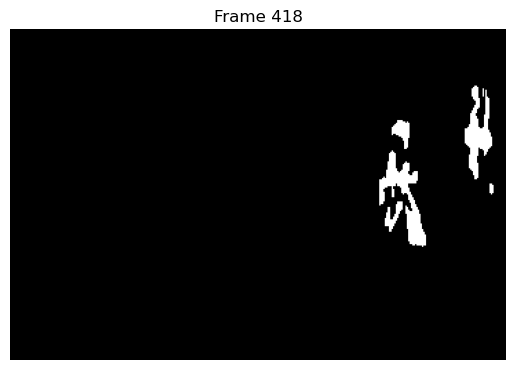

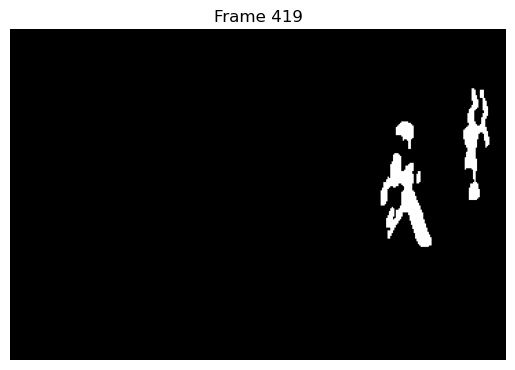

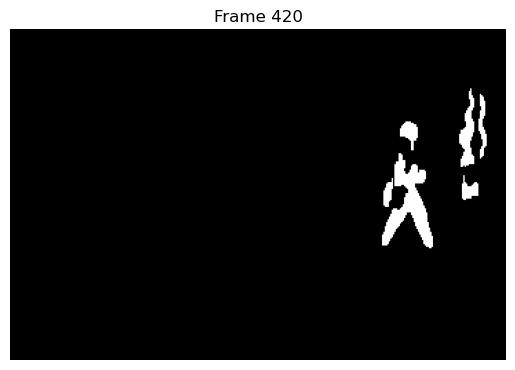

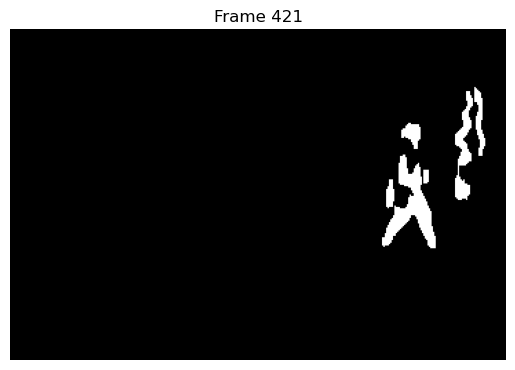

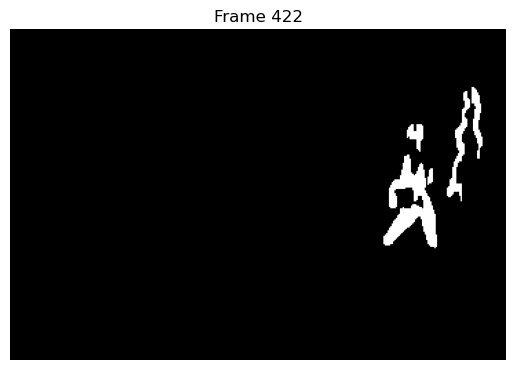

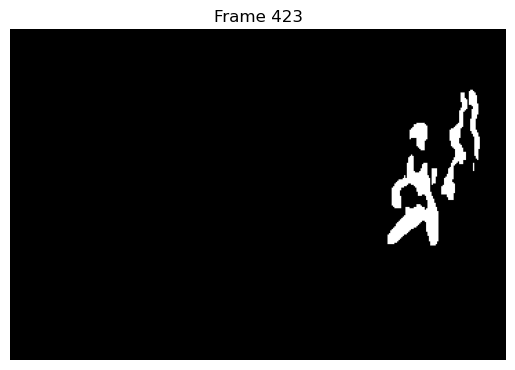

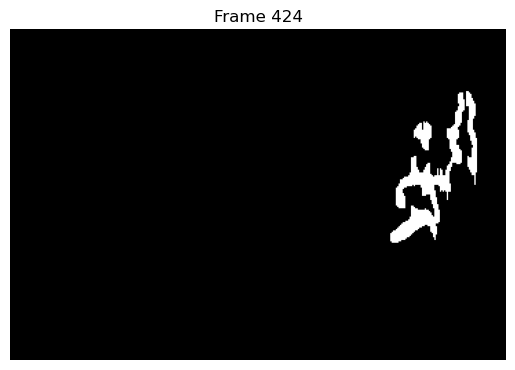

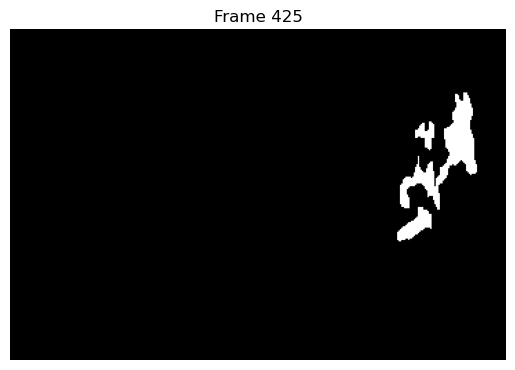

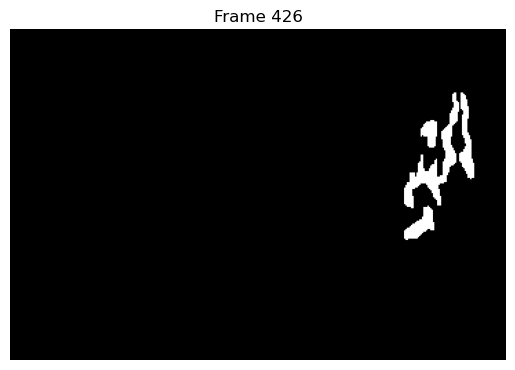

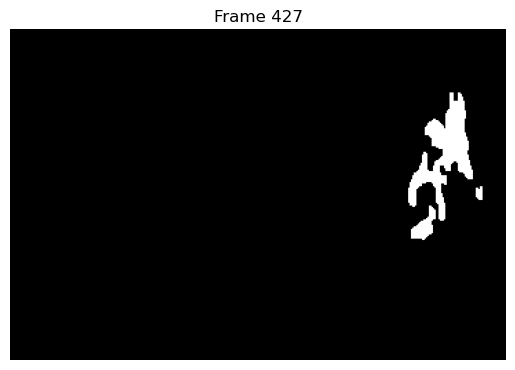

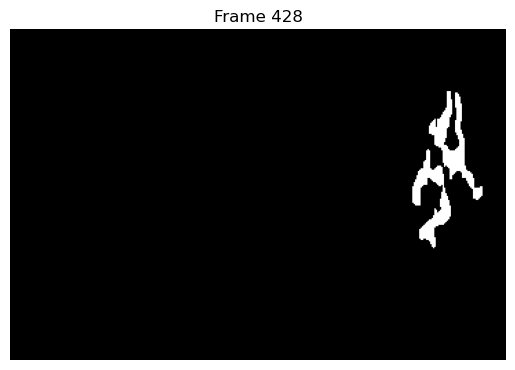

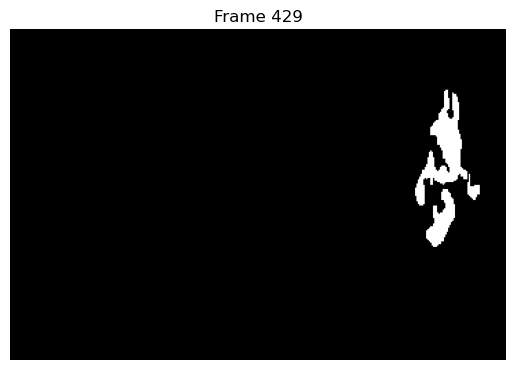

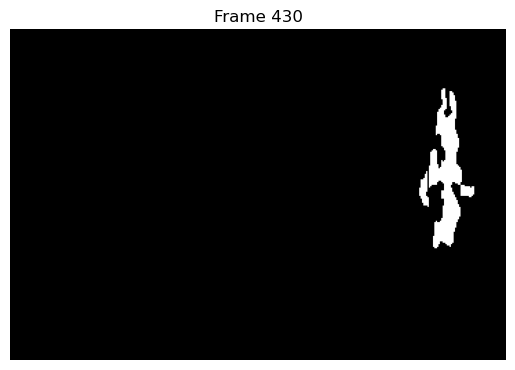

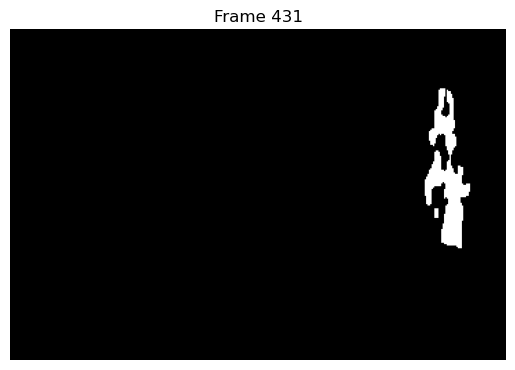

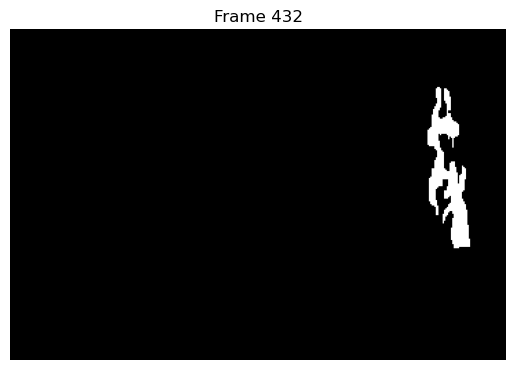

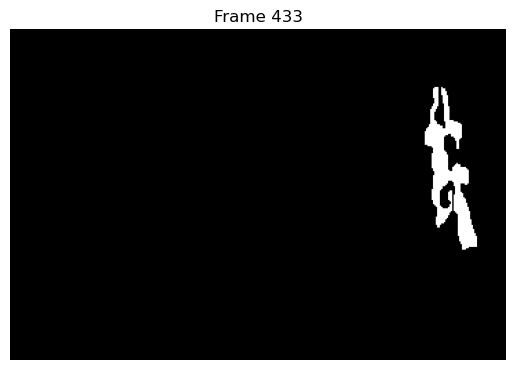

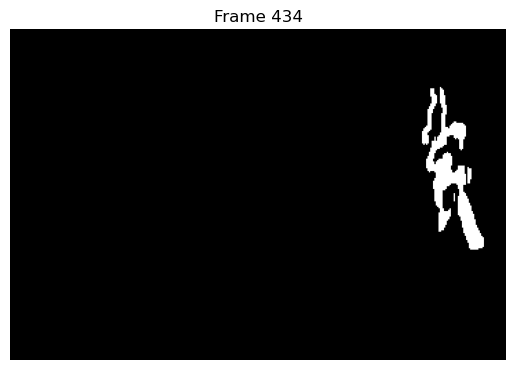

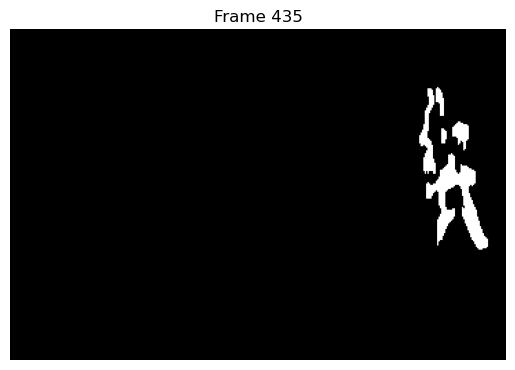

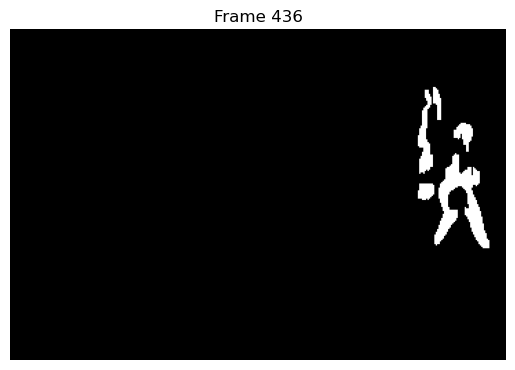

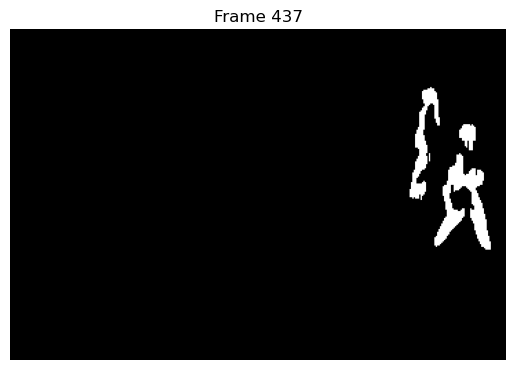

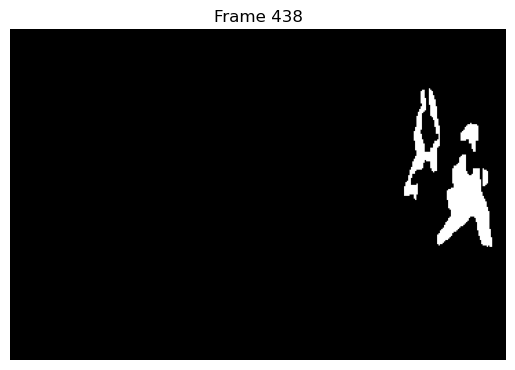

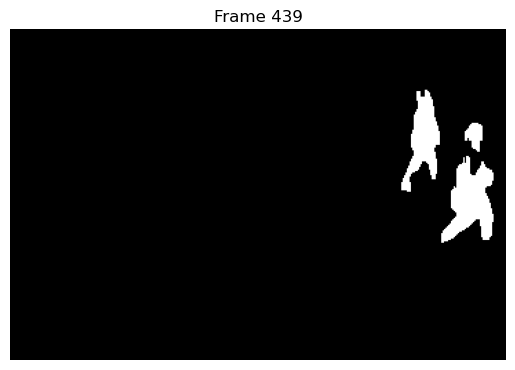

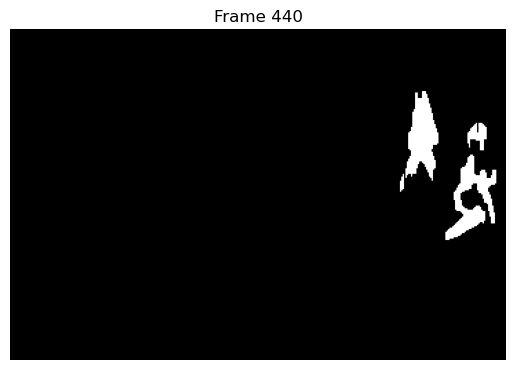

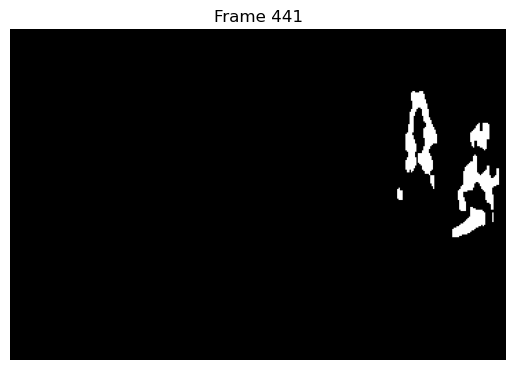

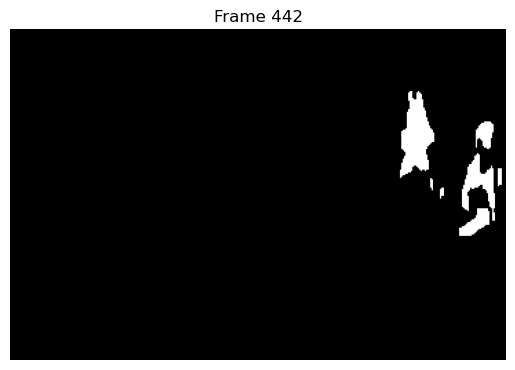

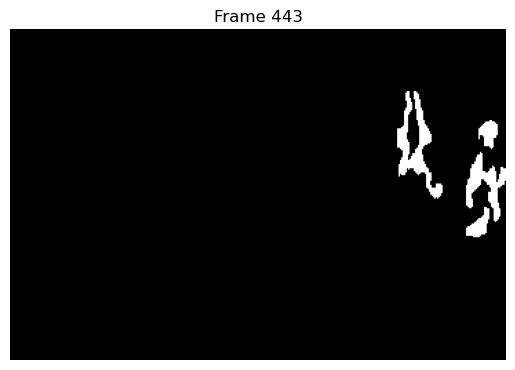

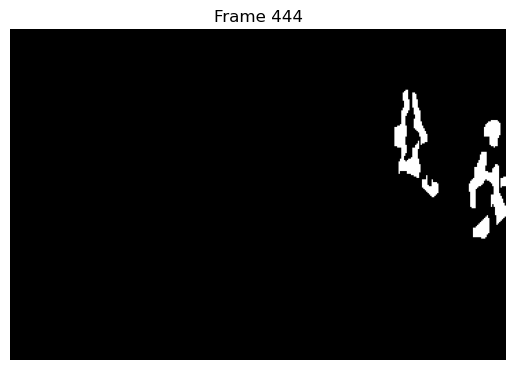

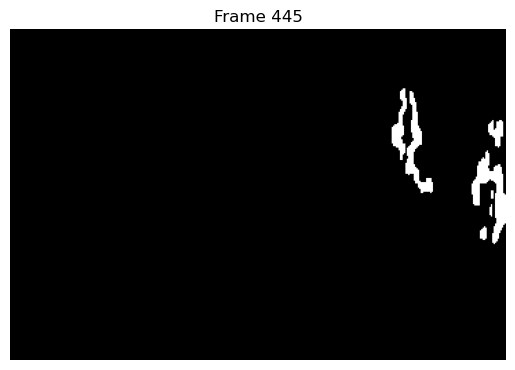

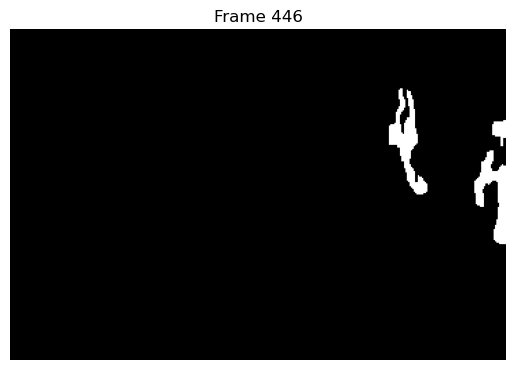

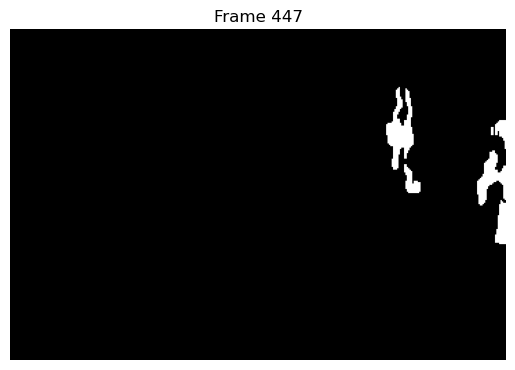

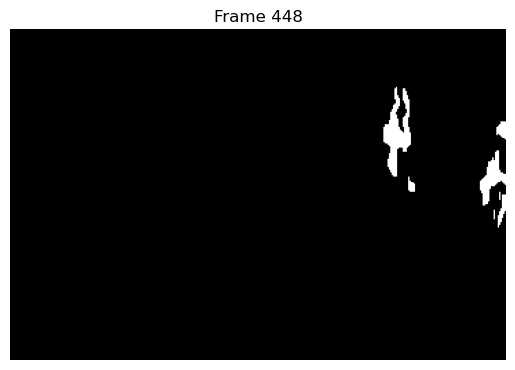

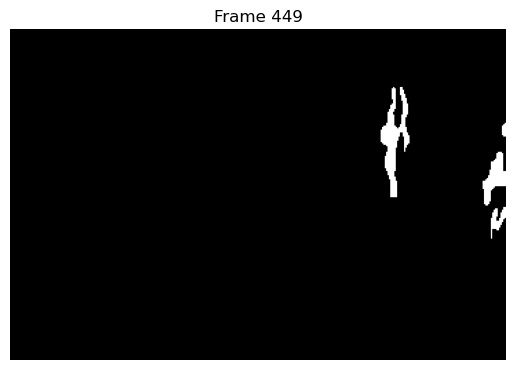

In [66]:
import matplotlib.pyplot as plt

for i in range(400, 450):
    plt.imshow(process_movement(i, img_pedestrian), cmap='gray')
    plt.axis('off')
    plt.title(f"Frame {i}")
    plt.show()

### Image labeling

In [67]:
retval, labels, stats, centroids = cv2.connectedComponentsWithStats(test_image)
# retval -- total number of unique labels
# labels -- destination labelled image
# stats -- statistics output for each label ,including the background label. (x, y, width, heigh, area)
# centroids -- centroid output for each label ,including the background label.

print(retval)
print(labels)
print(stats)
print(centroids)

14
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[    0     0   360   240 82694]
 [  228    44    25    66   997]
 [   41    57    48    75  1833]
 [   79    62     3     6    18]
 [   28    97    11    23   141]
 [   20    98     9    22   110]
 [   67    98    15    33   278]
 [   89   102     7    19   105]
 [   99   105     3     8    20]
 [  225   111     1     6     6]
 [   94   118     7    13    55]
 [   24   121    15    10   119]
 [   87   125     1     6     6]
 [   89   124     3     7    18]]
[[182.66544127 120.72312381]
 [240.90972919  78.64894684]
 [ 59.90398254  89.25368249]
 [ 80.          64.5       ]
 [ 33.12765957 106.83687943]
 [ 23.67272727 108.34545455]
 [ 74.01438849 115.53597122]
 [ 91.77142857 111.54285714]
 [100.05       108.2       ]
 [225.         113.5       ]
 [ 97.32727273 124.65454545]
 [ 31.09243697 125.91596639]
 [ 87.         127.5       ]
 [ 90.         126.83333333]]


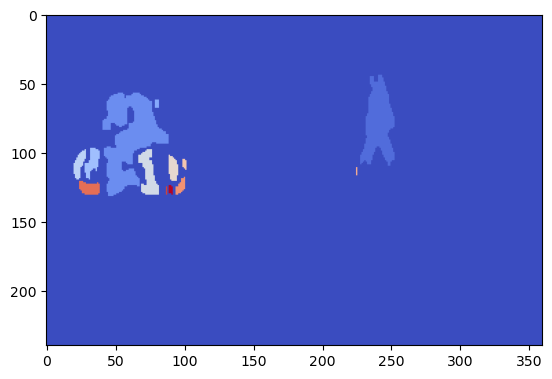

In [68]:
plt.imshow(labels, cmap="coolwarm")

### Drawing a frame around the object with largest area

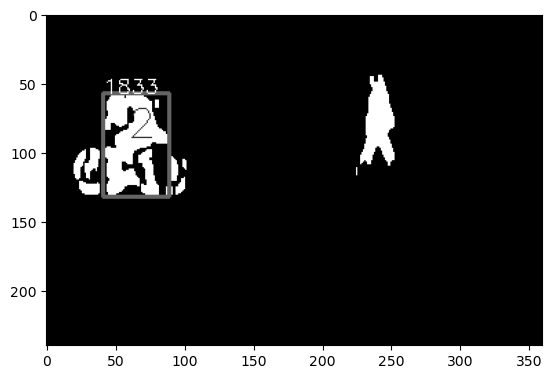

In [69]:
I_VIS = test_image.copy() # copy of the input image
if (stats.shape[0] > 1): # are there any objects
  tab = stats[1:, 4] # 4 columns without first element
  pi = np.argmax(tab) + 1 # finding the index of the largest item
  # drawing a bbox
  cv2.rectangle(I_VIS, (stats[pi, 0], stats[pi, 1]), (stats[pi, 0] + stats[pi, 2], stats[pi, 1] + stats [pi, 3]), (100, 0, 0), 2)
  # print information about the field and the number of the largest element
  cv2.putText(I_VIS, "%d" % stats[pi ,4], (stats[pi, 0], stats[pi, 1]), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0))
  cv2.putText(I_VIS, "%d" % pi, (np.int64(centroids[pi, 0]), np.int64(centroids[pi, 1])), cv2.FONT_HERSHEY_SIMPLEX, 1, (50, 0, 0))

plt.imshow(I_VIS)

### Classification metrics


In [70]:
def precision(image, ground_truth):
    TP = ((image == 255) & (ground_truth == 255)).sum()
    FP = ((image == 255) & (ground_truth == 0)).sum()

    return TP / (TP + FP) if (TP + FP) > 0 else 0


In [71]:
def recall(image, ground_truth):
    TP = ((image == 255) & (ground_truth == 255)).sum()
    FN = ((image == 0) & (ground_truth == 255)).sum()

    return TP / (TP + FN) if (TP + FN) > 0 else 0

In [72]:
def F1_score(image, ground_truth):
  precision_value = precision(image, ground_truth)
  recall_value = recall(image, ground_truth)

  if precision_value + recall_value == 0:
      return 0

  return (2 * precision_value * recall_value) / (precision_value +  recall_value)

### Pedestrians


In [73]:
processed_images = [process_movement(i, img_pedestrian) for i in range(2, len(img_pedestrian))]
ground_truth = gt_pedestrian

In [74]:
p_scores = []
r_scores = []
f1_scores = []
start, end = 300, 399
for i in range(len(processed_images)):
  if i >= start and i <= end:
    p_scores.append(precision(processed_images[i], ground_truth[i]))
    r_scores.append(recall(processed_images[i], ground_truth[i]))
    f1_scores.append(F1_score(processed_images[i], ground_truth[i]))

In [75]:
print(sum(p_scores) / len(p_scores))
print(sum(r_scores) / len(r_scores))
print(sum(f1_scores) / len(f1_scores))

0.5148342445934435
0.41363128048261855
0.4483147731030229


### Highway

In [76]:
processed_images = [process_movement(i, img_highway) for i in range(2, len(img_highway))]
ground_truth = gt_highway

In [77]:
p_scores = []
r_scores = []
f1_scores = []
start, end = 470, 1700
for i in range(len(processed_images)):
  if i >= start and i <= end:
    p_scores.append(precision(processed_images[i], ground_truth[i]))
    r_scores.append(recall(processed_images[i], ground_truth[i]))
    f1_scores.append(F1_score(processed_images[i], ground_truth[i]))

In [78]:
print(sum(p_scores) / len(p_scores))
print(sum(r_scores) / len(r_scores))
print(sum(f1_scores) / len(f1_scores))

0.867742415712368
0.3572794166487399
0.4855508846461395


### Office

In [79]:
processed_images = [process_movement(i, img_office) for i in range(2, len(img_office))]
ground_truth = gt_office

In [80]:
p_scores = []
r_scores = []
f1_scores = []
start, end = 570, 2050
for i in range(len(processed_images)):
  if i >= start and i <= end:
    p_scores.append(precision(processed_images[i], ground_truth[i]))
    r_scores.append(recall(processed_images[i], ground_truth[i]))
    f1_scores.append(F1_score(processed_images[i], ground_truth[i]))

In [81]:
print(sum(p_scores) / len(p_scores))
print(sum(r_scores) / len(r_scores))
print(sum(f1_scores) / len(f1_scores))

0.5188775985693036
0.03575234293563757
0.05880144531271994
